Created by: Andreas Loizias
Created on: 2026/03/09

This is a galaxy classification model using NN. The dataset is the Galaxy 10 DECaLS dataset that can be found atv https://astronn.readthedocs.io/en/latest/galaxy10.html
It consists of a set of images with the galaxy classification and the objective is to train a NN model to correctly classify a test dataset.

In [1]:
# Find the fataset h5 file
import os

os.listdir('/kaggle/input/datasets/andreasloizias/galaxy-10-decals')

['Galaxy10_DECals.h5']

In [2]:
#Load the dataset to images and labels arrays
import h5py
import numpy as np

path = "/kaggle/input/datasets/andreasloizias/galaxy-10-decals/Galaxy10_DECals.h5"

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["ans"])

print(images.shape)
print(labels.shape)

(17736, 256, 256, 3)
(17736,)


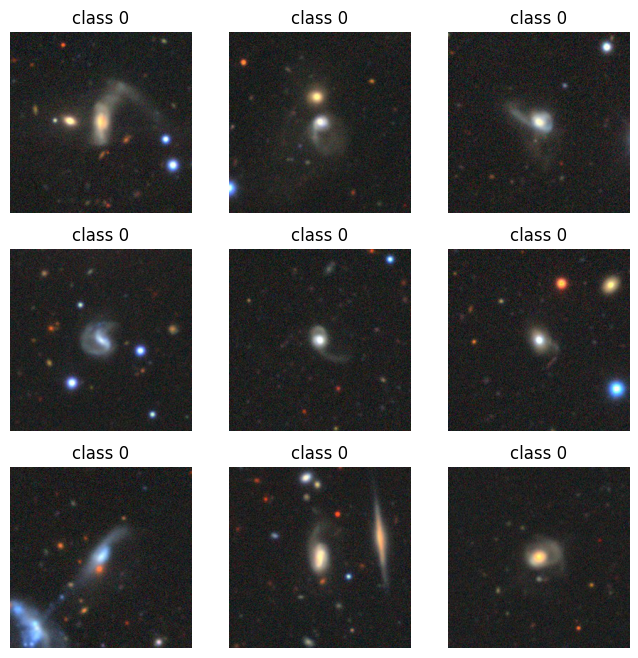

In [3]:
#Inspect the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(f"class {labels[i]}")
    plt.axis("off")

plt.show()

In [5]:
#Split the images to the x array which will be the attributes of the model, and the labels to the y array which is the classification output
X = images
y = labels

In [6]:
#Inspect the counts for each category. The labels are 0-9 so we just label them to make it easier to read
labels = [
"Disturbed",
"Merging",
"Round Smooth",
"In-between Smooth",
"Cigar Smooth",
"Barred Spiral",
"Unbarred Spiral",
"Edge-on no bulge",
"Edge-on bulge",
"Spiral"
]

classes, counts = np.unique(y, return_counts=True)

for c, n in zip(classes, counts):
    print(f"{labels[c]}: {n}")

Disturbed: 1081
Merging: 1853
Round Smooth: 2645
In-between Smooth: 2027
Cigar Smooth: 334
Barred Spiral: 2043
Unbarred Spiral: 1829
Edge-on no bulge: 2628
Edge-on bulge: 1423
Spiral: 1873


In [7]:
#split the data into train and temp... 70:30 %
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=22
)

#split the temp data to test and validation 50:50 %
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=22
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (12415, 256, 256, 3)
Validation: (2660, 256, 256, 3)
Test: (2661, 256, 256, 3)


In [9]:
# Reduce the size of the images to 128x128 as the original 256x256 was causing memory errors
import tensorflow as tf
import numpy as np

X_train = tf.image.resize(X_train, (128, 128)).numpy()
X_val   = tf.image.resize(X_val, (128, 128)).numpy()
X_test  = tf.image.resize(X_test, (128, 128)).numpy()

print(X_train.shape, X_val.shape, X_test.shape)

(12415, 128, 128, 3) (2660, 128, 128, 3) (2661, 128, 128, 3)


In [10]:
#normalize the data... the data are images with pixels from 0-127 so we divide my 128 to make it 0-1.0
import numpy as np

X_train = X_train.astype(np.float32) / 128.0
print("X_train done")

X_val = X_val.astype(np.float32) / 128.0
print("X_val done")

X_test = X_test.astype(np.float32) / 128.0
print("X_test done")

X_train done
X_val done
X_test done


In [ ]:
print(X_train.shape)

In [11]:
# compute class weight to handle the imbalance of the dataset where you have far fewer data for one category over the other
# NOT APPLIICABLE ANYMORE AS WE REMOVED CLASS WEIGHTS SINCE IT WAS NOT HELPING WITH THE ACCURACY
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.uint8(0): np.float64(1.6400264200792602), np.uint8(1): np.float64(0.9572089437162683), np.uint8(2): np.float64(0.6707185305240411), np.uint8(3): np.float64(0.8749119097956307), np.uint8(4): np.float64(5.305555555555555), np.uint8(5): np.float64(0.8681818181818182), np.uint8(6): np.float64(0.969921875), np.uint8(7): np.float64(0.6747282608695652), np.uint8(8): np.float64(1.2464859437751004), np.uint8(9): np.float64(0.9469870327993898)}


Now we begin by defining and training the model

In [26]:
#Define the keras CNN model
# We have 4 convoluted 2D layers
# a dense layer
# a dropout layer to randomly disable neurons to prevent overfitting
# output layer using softmax activation function as it is categorical output
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization
)

tf.keras.backend.clear_session()

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,202 (453.91 KB)

 Trainable params: 115,722 (452.04 KB)

 Non-trainable params: 480 (1.88 KB)

In [27]:
#compile the model
# use sparse categorical cross entropy for the loss function
# uses adam for the weight optimizer
# reports on accuracy
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
#train the model on 11 epochs, with batch size 4 (for memory issues)
# added early stopping to improve accuracy from previous version
# changed epochs and batch size
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=11,
    batch_size=4,
    callbacks=[early_stop]
)

Epoch 1/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 190s 61ms/step - accuracy: 0.3879 - loss: 1.6692 - val_accuracy: 0.4966 - val_loss: 1.3961
Epoch 2/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 191s 61ms/step - accuracy: 0.4798 - loss: 1.4162 - val_accuracy: 0.4207 - val_loss: 1.7572
Epoch 3/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 189s 61ms/step - accuracy: 0.5447 - loss: 1.2676 - val_accuracy: 0.5966 - val_loss: 1.4105
Epoch 4/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - accuracy: 0.5921 - loss: 1.1623 - val_accuracy: 0.6252 - val_loss: 1.0972
Epoch 5/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - accuracy: 0.6369 - loss: 1.0630 - val_accuracy: 0.6425 - val_loss: 1.0597
Epoch 6/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 188s 61ms/step - accuracy: 0.6514 - loss: 1.0167 - val_accuracy: 0.6756 - val_loss: 0.9987
Epoch 7/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - accuracy: 0.6731 - loss: 0.9529 - val_accuracy: 0.5895 - val_loss: 1.1637
Epoch 8/15
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - accuracy: 

In [32]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.7099 - loss: 0.8388
Test accuracy: 0.7110108733177185
Test loss: 0.8589908480644226


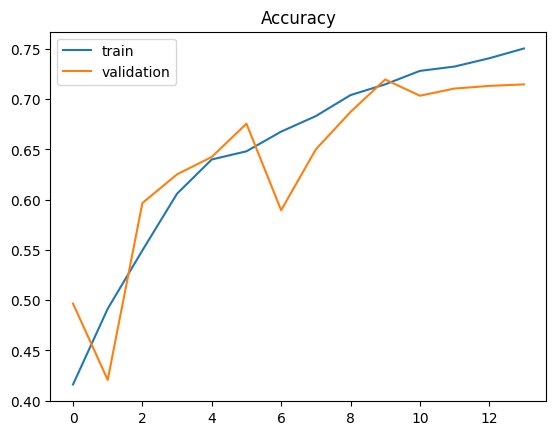

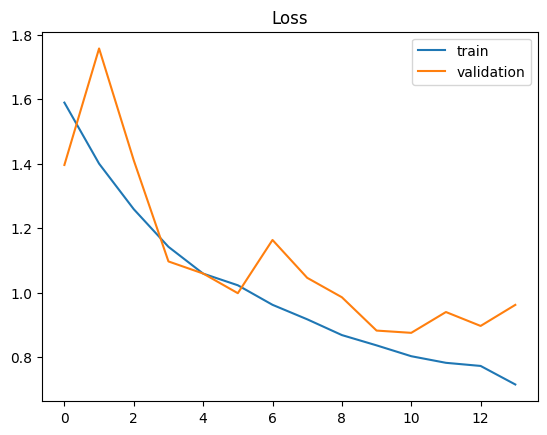

In [33]:
# visualize the model metrics
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.title("Loss")
plt.show()

84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step
              precision    recall  f1-score   support

           0       0.37      0.30      0.33       162
           1       0.79      0.69      0.74       278
           2       0.83      0.90      0.87       397
           3       0.70      0.94      0.81       304
           4       0.79      0.38      0.51        50
           5       0.68      0.78      0.73       307
           6       0.64      0.64      0.64       275
           7       0.64      0.46      0.54       394
           8       0.70      0.81      0.75       213
           9       0.81      0.78      0.79       281

    accuracy                           0.71      2661
   macro avg       0.70      0.67      0.67      2661
weighted avg       0.71      0.71      0.70      2661



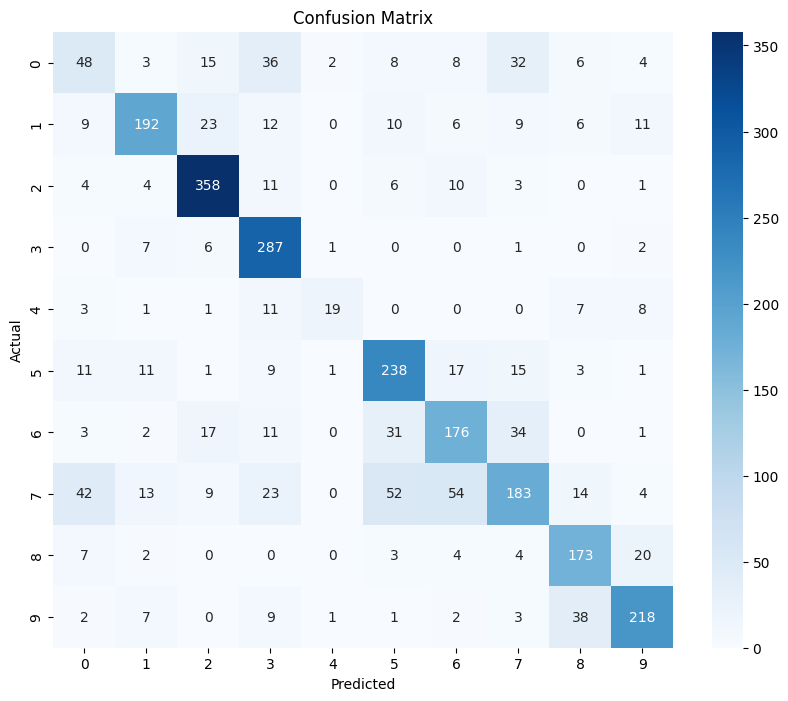

In [34]:
# analyze the model using a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**CONCLUSSION:**

We started out with a simple CNN model which had a very low accuracy (~14%) and ended up with a more complex model with early stopping and got a much better accuracy (~71%).
We actually tested for 15 epochs but came to the conclussion that 11 epochs is enough. The model did not improve significantly after that.
From the confusion matrix we see that over it did very well except for class 4 which is cigar shaped galaxies since our data sample contained far fewer examples of that
class than the other classes.